In [1]:
# Lo monto en Colab porque es como pude manejar
# mi volumen grande de datos inicial

from google.colab import drive, files
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
# Utilidades generales
# Las demás van apareciendo sobre la marcha

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Índices Navideños
## Introducción a la Ciencia de Datos
### Juan Pablo Rodríguez Villagrán

#### 1. Procesado de datos originales
En esta primera parte, se hace un pre-procesamiento de datos. El conjunto de datos original pesa 3.5GB.


El pre-procesamiento consiste precisamente en la selección de variables de interés y posteriormente en el filtrado de filas correspondiente a los países elegidos.

In [ ]:
# Este es el conjunto de datos original

# original = pd.read_csv("/content/drive/MyDrive/CienciaDeDatos/Proyecto/spotify_charts_2017_2021.csv")

In [ ]:
# Exploración de columnas y estandarización de tipos de datos

print("Columnas disponibles:", original.columns.tolist())

original["date"] = pd.to_datetime(original["date"])
original["streams"] = pd.to_numeric(original["streams"], errors='coerce')

In [ ]:
# Selección de variables

df_core = original[["date", "region", "title", "artist", "rank", "streams", "chart"]].copy()
# print(len(df_core))

In [ ]:
# Definición de años de estudio y de años Navidad
# Filtrado por años Navidad

YEARS = list(range(2017, 2022))

df_core["navidad_year"] = df_core["date"].dt.year
df_core.loc[df_core["date"].dt.month == 1, "navidad_year"] = df_core["date"].dt.year - 1

df_core = df_core[df_core["navidad_year"].isin(YEARS)].copy()

# print(len(df_core))

In [ ]:
# Función que genera el filtro para fechas de Navidad

def crear_mascara_navidad(df):
    """Crea máscara para períodos de navidad: nov-dic (año actual) y ene (año siguiente)"""
    mascara = pd.Series(False, index=df.index)

    for year in YEARS:
        # Noviembre y Diciembre del año actual
        start_nov = pd.Timestamp(year, 11, 15)
        end_dic = pd.Timestamp(year, 12, 31)

        # Enero del año siguiente
        start_ene = pd.Timestamp(year + 1, 1, 1)
        end_ene = pd.Timestamp(year + 1, 1, 7)

        # Combinar máscaras
        periodo_navidad = (
            ((df["date"] >= start_nov) & (df["date"] <= end_dic)) |
            ((df["date"] >= start_ene) & (df["date"] <= end_ene))
        )

        mascara = mascara | periodo_navidad

    return mascara

In [ ]:
# Selección de los datos de periodos navideños

mask_navidad = crear_mascara_navidad(df_core)
df_navidad = df_core[mask_navidad].copy()

# print(len(df_navidad))

In [ ]:
# Ver qué países están en el dataset

# df_navidad["region"].unique()

In [ ]:
# Filtrado por países de interés

REGIONES = ["Mexico", "United States", "United Kingdom", "Japan", "Argentina", "Canada", "Egypt", "South Korea", "Global"]
df_navidad = df_navidad[df_navidad["region"].isin(REGIONES)].copy()
# print(len(df_navidad))

In [ ]:
# Descargar como csv
# (para no tener en el espacio de trabajo el gigante)

df_navidad.to_csv('spotify_daily_panel_navidad.csv', index=False)
files.download('spotify_daily_panel_navidad.csv')

#### 2. Construcción del índice
Es importante que desde aquí se utilice el conjunto de datos pequeñito (que de todos modos pesa 34 MB).

In [3]:
df_navidad = pd.read_csv("/content/drive/MyDrive/CienciaDeDatos/Proyecto/spotify_daily_panel_navidad.csv")

In [4]:
# Agrupación por región, canción=(título,artista) y año Navidad

group_cols = ["region", "title", "artist", "navidad_year"]

agg = (
    df_navidad
    .groupby(group_cols)
    .agg(
        max_streams=("streams", "max"),
        best_rank=("rank", "min"),
        days_in_chart=("date", "nunique"),
    )
    .reset_index()
)

# agg.head()

In [5]:
# Construcción de las estadísticas S y M

total_by_year = (
    agg
    .groupby(["region", "navidad_year"])["max_streams"]
    .sum()
    .rename("total_max_streams")
    .reset_index()
)

agg2 = agg.merge(total_by_year, on=["region", "navidad_year"], how="left")
agg2["share"] = agg2["max_streams"] / agg2["total_max_streams"]

# agg2.head()

In [7]:
# Resumen por region (d) y canción (s=(title,artist))
# Construcción de otras estadísticas como P y B
# Se supone que summary va a tener la info expandida con las estadísticas

group_song = ["region", "title", "artist"]

summary = (
    agg2
    .groupby(group_song)
    .agg(
        years_present=("navidad_year", "nunique"),
        mean_share=("share", "mean"),
        top5_hits=("best_rank", lambda x: (x <= 5).sum()),
        mean_best_rank=("best_rank", "mean"),
    )
    .reset_index()
)

# summary.head()

In [8]:
# La función para calcular z-scores regionales

def zscore_by_region(df, col, region_col="region"):

    return df.groupby(region_col)[col].transform(
        lambda x: (x - x.mean()) / (x.std(ddof=0) if x.std(ddof=0) > 0 else 1.0)
    )

In [9]:
# Agregado de z-scores regionales al summary

summary["z_years"] = zscore_by_region(summary, "years_present")
summary["z_mean_share"] = zscore_by_region(summary, "mean_share")

summary["z_top5"] = zscore_by_region(summary, "top5_hits")

In [11]:
# AQUÍ ES DONDE SE DEFINE EL XMASSCORE

gam = 0.5

summary["xmas_score_charts"] = (
    summary["z_years"] +
    summary["z_mean_share"] +
    gam * summary["z_top5"]
)

In [12]:
# Canciones por país ordenadas respecto a su xmasscore

summary_sorted = (
    summary
    .sort_values(["region", "xmas_score_charts"], ascending=[True, False])
    .reset_index(drop=True)
)

# summary_sorted.head()
# summary_sorted[summary_sorted["region"] == "Japan"].head()

In [14]:
# El top_5 por región

tabla_top = (
    summary_sorted
    .groupby("region")
    .head(5)
    .reset_index(drop=True)
    [["region", "title", "artist", "xmas_score_charts"]]
)

# tabla_top     # Este resultado está reportado

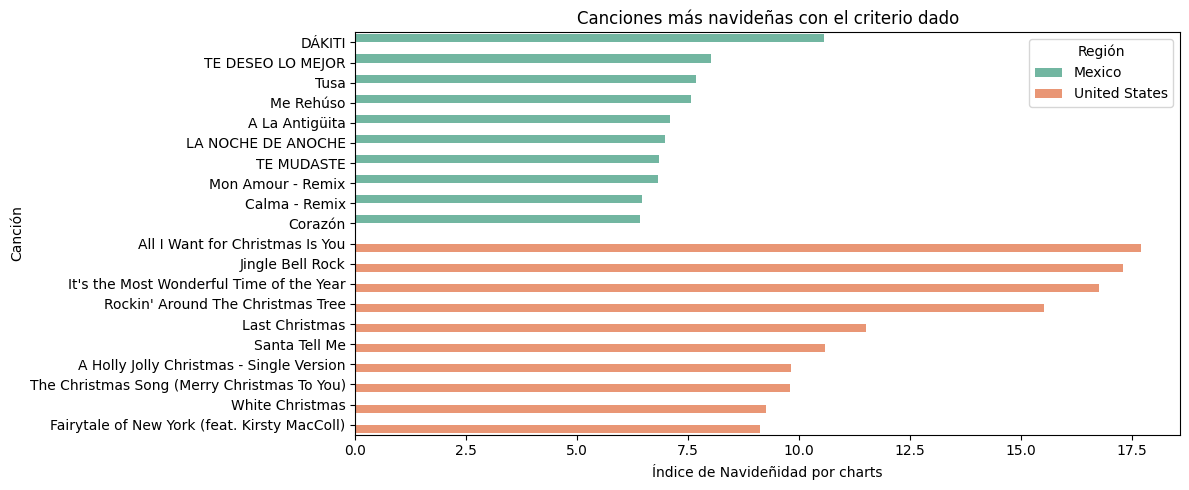

In [15]:
# Comparación del top 10 de México con el de USA

regiones_visualizar = ["Mexico", "United States"]

top_por_region = (
    summary_sorted
    [summary_sorted["region"].isin(regiones_visualizar)]
    .groupby("region")
    .head(10)
)

plt.figure(figsize=(12,5))
sns.barplot(
    data=top_por_region,
    x="xmas_score_charts",
    y="title",
    hue="region",
    dodge=True,
    palette="Set2"
)
plt.xlabel("Índice de Navideñidad por charts")
plt.ylabel("Canción")
plt.title("Canciones más navideñas con el criterio dado")
plt.legend(title="Región")
plt.tight_layout()
plt.savefig("MexvsUK.pdf")
plt.show()

/tmp/ipython-input-221708036.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


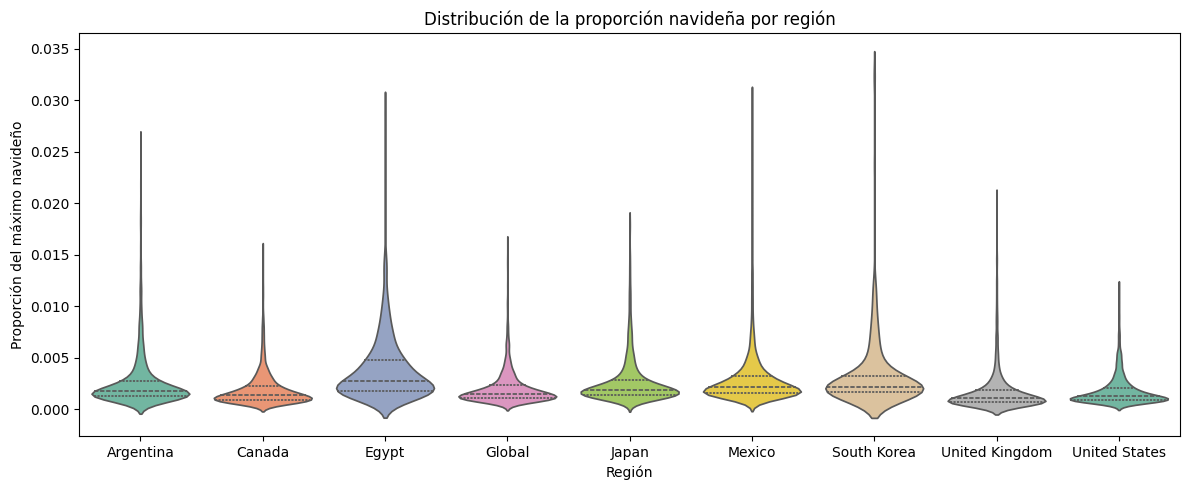

In [16]:
# Violinplot para comparar distribución navideña por región

plt.figure(figsize=(12,5))
sns.violinplot(
    data=agg2,
    x="region",
    y="share",
    inner="quartile",
    palette="Set2"
)

plt.title("Distribución de la proporción navideña por región")
plt.xlabel("Región")
plt.ylabel("Proporción del máximo navideño")
plt.tight_layout()
plt.savefig("violin.pdf")
plt.show()

In [20]:
# Creación de un id para canciones y definición como metadata

df_songs = summary_sorted.copy()
df_songs["song_id"] = df_songs["title"] + " — " + df_songs["artist"]

song_meta = (
    df_songs[["song_id", "title", "artist"]]
    .drop_duplicates()
    .set_index("song_id")
)

In [19]:
# DEFINICIÓN DE MATRIZ (tensor xd) DE DATOS X=(X_{s,p})
# ===== MUY IMPORTANTE ===== #

mat = (
    df_songs
    .pivot_table(
        index="song_id",
        columns="region",
        values="xmas_score_charts",
        aggfunc="mean"   # por si la misma canción apareció varias veces
    )
    .fillna(0.0)
)

# mat.head()

In [21]:
# Revisión de ranking por índice de globalidad

song_scores = mat.copy()
regions = song_scores.columns

presence = (song_scores > 0).sum(axis=1)
G = presence / len(regions)

song_global_stats = pd.DataFrame({
    "G": G,
})

# song_global_stats.head()

topG = (
    song_global_stats
    .sort_values("G", ascending=False)
    .head(20)
)

topG_pretty = topG.join(song_meta, how="left")
# topG_pretty[["title", "artist", "G"]]

,title,artist,G
song_id,,,
abcdefu — GAYLE,abcdefu,GAYLE,1.000000
Blinding Lights — The Weeknd,Blinding Lights,The Weeknd,0.888889
Someone You Loved — Lewis Capaldi,Someone You Loved,Lewis Capaldi,0.888889
STAY (with Justin Bieber) — The Kid LAROI,STAY (with Justin Bieber),The Kid LAROI,0.888889
SAD GIRLZ LUV MONEY Remix (feat. Kali Uchis and Moliy) — Amaarae,SAD GIRLZ LUV MONEY Remix (feat. Kali Uchis an...,Amaarae,0.888889
All I Want for Christmas Is You — Mariah Carey,All I Want for Christmas Is You,Mariah Carey,0.888889
Santa Tell Me — Ariana Grande,Santa Tell Me,Ariana Grande,0.888889
Dance Monkey — Tones And I,Dance Monkey,Tones And I,0.888889
"Señorita — Shawn Mendes, Camila Cabello",Señorita,"Shawn Mendes, Camila Cabello",0.777778


#### 3. La parte de clustering
Se necesita un método *no supervisado* porque tal cual no existe la etiqueta "Canción Navideña" en los charts.

Aquí exploramos $K$-means y spectral clustering.

**Aclaración metodológica:** puede que el estadístico de silueta o la validación cruzada sugieran $K\geq 2$, pero al final se agruparán clusteres para obtener la "binarización" buscada.

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

##### 3.1. Con $K$-means
Aquí se hacen el proceso de ubicación de *canciones navideñas* y de *países navideños* con $K$-means.

Se revisan los casos de preprocesamiento por escalado y por PCA.

In [37]:
from sklearn.cluster import KMeans

###### 3.1.1. Con escalado para las canciones

In [38]:
# Traemos los datos al formato que necesitamos y escalamos

X = mat.values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K=2: Silhouette Score = 0.7362
K=3: Silhouette Score = 0.6905
K=4: Silhouette Score = 0.6928
K=5: Silhouette Score = 0.6325
K=6: Silhouette Score = 0.6356
K=7: Silhouette Score = 0.5709
K=8: Silhouette Score = 0.1851
K=9: Silhouette Score = 0.2080
K=10: Silhouette Score = 0.1986
K=11: Silhouette Score = 0.2175
K=12: Silhouette Score = 0.2207
K=13: Silhouette Score = 0.2425
K=14: Silhouette Score = 0.2052
K=15: Silhouette Score = 0.2305
K=16: Silhouette Score = 0.2324
K=17: Silhouette Score = 0.2386
K=18: Silhouette Score = 0.2458
K=19: Silhouette Score = 0.2455


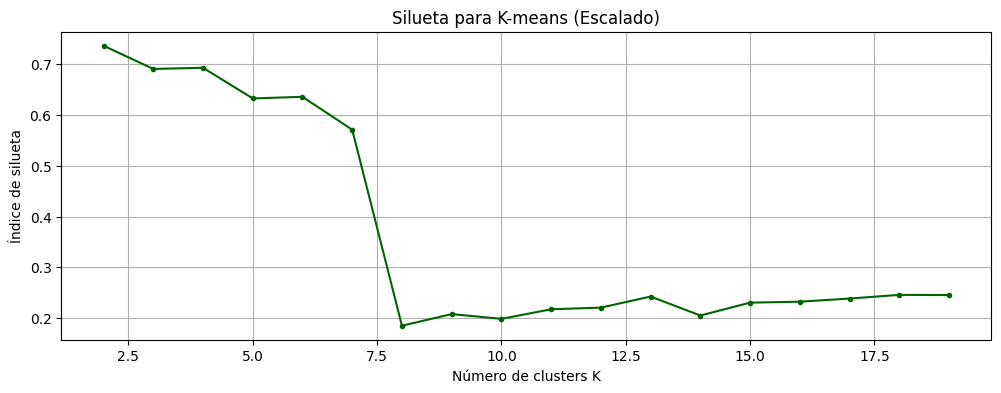

In [39]:
# Va la silueta para elegir el K óptimo

K_range = range(2, 20)
sil_scores = []

for K in K_range:
    kmeans = KMeans(n_clusters=K, random_state=1008, n_init='auto')
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"K={K}: Silhouette Score = {score:.4f}")

# Gráfico de silueta
plt.figure(figsize=(12, 4))
plt.plot(K_range, sil_scores, marker='o', markersize=3, color='darkgreen')
plt.xlabel('Número de clusters K')
plt.ylabel('Índice de silueta')
plt.title('Silueta para K-means (Escalado)')
plt.grid(True)
plt.savefig("silueta.pdf")
plt.show()

In [40]:
# Evaluación con el K óptimo

k_optimo = 8
kmeans_optimo = KMeans(n_clusters=k_optimo, random_state=1008, n_init='auto')
clusters_optimo = kmeans_optimo.fit_predict(X_scaled)

In [41]:
# Evaluación con K=2

kmeans_k2 = KMeans(n_clusters=2, random_state=1008, n_init='auto')
clusters_k2 = kmeans_k2.fit_predict(X_scaled)

In [103]:
# Evaluación con K=3

kmeans_k3 = KMeans(n_clusters=3, random_state=1008, n_init='auto')
clusters_k3 = kmeans_k3.fit_predict(X_scaled)

In [42]:
# PCA para la visualización

pca = PCA(n_components=2, random_state=1008)
X_pca = pca.fit_transform(X_scaled)

In [104]:
# Para graficar ahorita...

df_esc = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster_Optimo': clusters_optimo,
    'Cluster_K2': clusters_k2,
    'Cluster_K3': clusters_k3
})

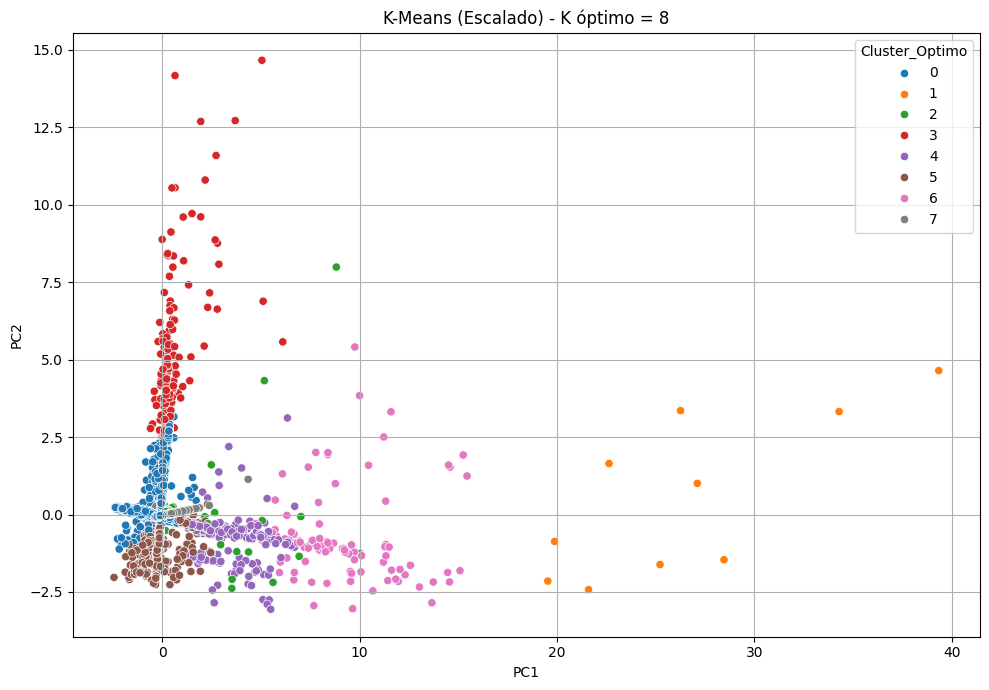

In [63]:
# Visualización K óptimo

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_esc, x='PC1', y='PC2', hue='Cluster_Optimo', palette='tab10')
plt.title(f'K-Means (Escalado) - K óptimo = {k_optimo}')
plt.grid(True)
plt.tight_layout()
plt.savefig("KoptKmeansEsc.pdf")
plt.show()

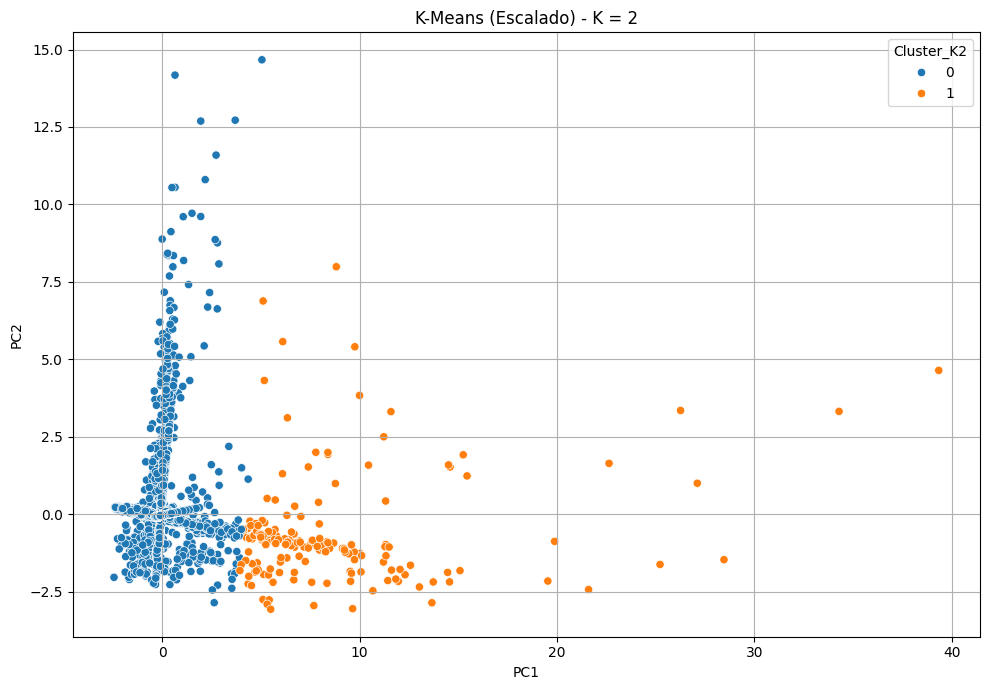

In [64]:
# Visualización K=2

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_esc, x='PC1', y='PC2', hue='Cluster_K2', palette='tab10')
plt.title(f'K-Means (Escalado) - K = 2')
plt.grid(True)
plt.tight_layout()
plt.savefig("K2KmeansEsc.pdf")
plt.show()

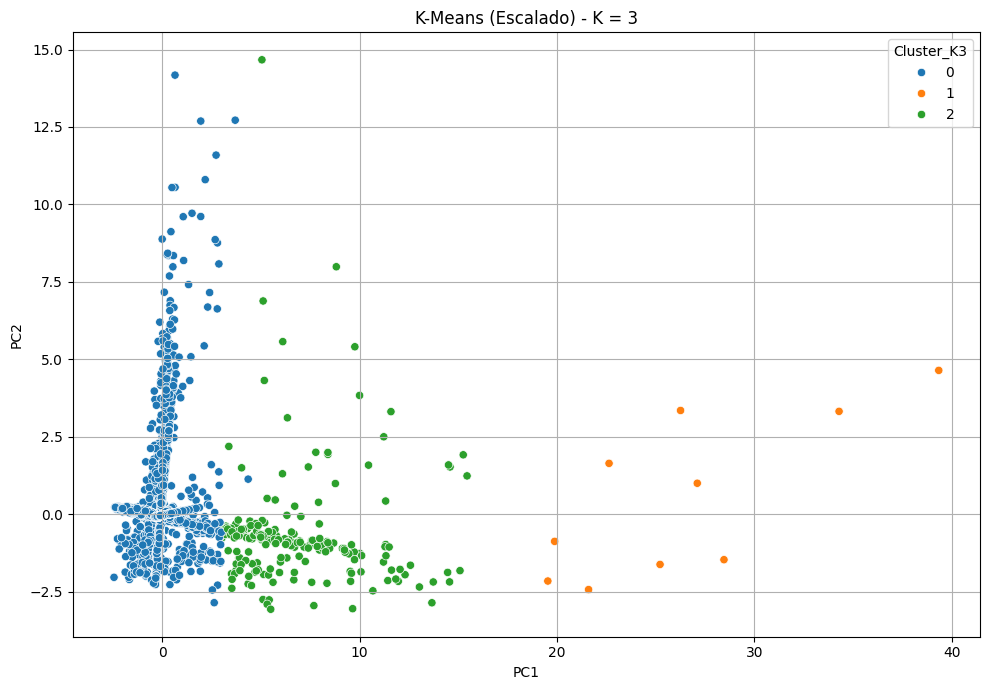

In [105]:
# Visualización K=3

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_esc, x='PC1', y='PC2', hue='Cluster_K3', palette='tab10')
plt.title(f'K-Means (Escalado) - K = 3')
plt.grid(True)
plt.tight_layout()
plt.savefig("K3KmeansEsc.pdf")
plt.show()

In [53]:
# Ver los elementos principales de los clusters
# Primero el de 8

mat_clusters = mat.copy()
mat_clusters['cluster'] = clusters_optimo
songs_clustered = mat_clusters.join(song_meta, how='left')

for c in range(k_optimo):
    print(f"\n=== Cluster {c} (K óptimo) ===")
    subset = songs_clustered[songs_clustered['cluster'] == c]
    subset = subset.assign(total_score=subset[mat.columns].sum(axis=1))
    display(subset[['title', 'artist', 'total_score']].head(10))
    print(f"Total canciones: {len(subset[['title', 'artist', 'total_score']])}")


=== Cluster 0 (K óptimo) ===


,title,artist,total_score
song_id,,,
#302 — Ken Hirai,#302,Ken Hirai,-0.837474
"#Natural — Paty Cantú, Juhn",#Natural,"Paty Cantú, Juhn",-0.027422
$€ Freestyle — Sfera Ebbasta,$€ Freestyle,Sfera Ebbasta,-0.990589
'Til You Can't — Cody Johnson,'Til You Can't,Cody Johnson,-1.323144
"'Till I Collapse — Eminem, Nate Dogg",'Till I Collapse,"Eminem, Nate Dogg",-1.851478
"'Zat You, Santa Claus? - Single Version — Louis Armstrong, The Commanders","'Zat You, Santa Claus? - Single Version","Louis Armstrong, The Commanders",-0.383598
(Sittin' On) the Dock of the Bay — Otis Redding,(Sittin' On) the Dock of the Bay,Otis Redding,-1.288970
(There's No Place Like) Home for the Holidays - 1959 Version — Perry Como,(There's No Place Like) Home for the Holidays ...,Perry Como,0.768304
(What A) Wonderful World - Mono — Sam Cooke,(What A) Wonderful World - Mono,Sam Cooke,-1.248276


Total canciones: 4440

=== Cluster 1 (K óptimo) ===


,title,artist,total_score
song_id,,,
All I Want for Christmas Is You — Mariah Carey,All I Want for Christmas Is You,Mariah Carey,101.905318
Do They Know It's Christmas? - 1984 Version — Band Aid,Do They Know It's Christmas? - 1984 Version,Band Aid,45.557560
Easy On Me — Adele,Easy On Me,Adele,47.635104
Fairytale of New York (feat. Kirsty MacColl) — The Pogues,Fairytale of New York (feat. Kirsty MacColl),The Pogues,53.157256
It's Beginning to Look a Lot like Christmas — Michael Bublé,It's Beginning to Look a Lot like Christmas,Michael Bublé,63.786162
It's the Most Wonderful Time of the Year — Andy Williams,It's the Most Wonderful Time of the Year,Andy Williams,57.857942
Jingle Bell Rock — Bobby Helms,Jingle Bell Rock,Bobby Helms,64.642084
Last Christmas — Wham!,Last Christmas,Wham!,86.465667
Rockin' Around The Christmas Tree — Brenda Lee,Rockin' Around The Christmas Tree,Brenda Lee,64.875670


Total canciones: 10

=== Cluster 2 (K óptimo) ===


...

Total canciones: 1319

=== Cluster 6 (K óptimo) ===


,title,artist,total_score
song_id,,,
A Holly Jolly Christmas - Single Version — Burl Ives,A Holly Jolly Christmas - Single Version,Burl Ives,30.738059
All I Want for Christmas Is You — Michael Bublé,All I Want for Christmas Is You,Michael Bublé,12.004539
All Too Well (10 Minute Version) (Taylor's Version) (From The Vault) — Taylor Swift,All Too Well (10 Minute Version) (Taylor's Ver...,Taylor Swift,26.733863
Baby It's Cold Outside (duet with Michael Bublé) — Idina Menzel,Baby It's Cold Outside (duet with Michael Bublé),Idina Menzel,14.399158
"Baby, It's Cold Outside (feat. Meghan Trainor) — Brett Eldredge","Baby, It's Cold Outside (feat. Meghan Trainor)",Brett Eldredge,17.995050
"Baby, It's Cold Outside — Dean Martin","Baby, It's Cold Outside",Dean Martin,21.189893
Blinding Lights — The Weeknd,Blinding Lights,The Weeknd,34.564416
Blue Christmas — Elvis Presley,Blue Christmas,Elvis Presley,24.823849
Can I Get It — Adele,Can I Get It,Adele,21.708092


Total canciones: 95

=== Cluster 7 (K óptimo) ===


,title,artist,total_score
song_id,,,
115万キロのフィルム — Official HIGE DANdism,115万キロのフィルム,Official HIGE DANdism,5.547893
2002 — Anne-Marie,2002,Anne-Marie,1.788980
366日 — HY,366日,HY,4.656053
AM11:00 — HY,AM11:00,HY,2.512635
BOY — King Gnu,BOY,King Gnu,2.740882
Boy With Luv (feat. Halsey) — BTS,Boy With Luv (feat. Halsey),BTS,1.579278
Butter — BTS,Butter,BTS,7.626504
CITRUS — Da-iCE,CITRUS,Da-iCE,2.715777
Chopstick — NiziU,Chopstick,NiziU,3.591601


Total canciones: 176


In [54]:
# Ahora el de K=2
mat_clusters_k2 = mat.copy()
mat_clusters_k2['cluster'] = clusters_k2
songs_clustered_k2 = mat_clusters_k2.join(song_meta, how='left')

for c in range(2):
    print(f"\n=== Cluster {c} (K=2) ===")
    subset = songs_clustered_k2[songs_clustered_k2['cluster'] == c]
    subset = subset.assign(total_score=subset[mat.columns].sum(axis=1))
    display(subset[['title', 'artist', 'total_score']].head(10))
    print(f"Total canciones: {len(subset[['title', 'artist', 'total_score']])}")


=== Cluster 0 (K=2) ===


,title,artist,total_score
song_id,,,
#302 — Ken Hirai,#302,Ken Hirai,-0.837474
"#Natural — Paty Cantú, Juhn",#Natural,"Paty Cantú, Juhn",-0.027422
"#Ysya2020 Vol. 5 - Silbando — YSY A, CLUB HATS",#Ysya2020 Vol. 5 - Silbando,"YSY A, CLUB HATS",-1.169647
"#Ysya2020 Vol. 6 - Un Flow de Infarto — YSY A, Bizarrap",#Ysya2020 Vol. 6 - Un Flow de Infarto,"YSY A, Bizarrap",-1.124688
$€ Freestyle — Sfera Ebbasta,$€ Freestyle,Sfera Ebbasta,-0.990589
'Til You Can't — Cody Johnson,'Til You Can't,Cody Johnson,-1.323144
"'Till I Collapse — Eminem, Nate Dogg",'Till I Collapse,"Eminem, Nate Dogg",-1.851478
"'Zat You, Santa Claus? - Single Version — Louis Armstrong, The Commanders","'Zat You, Santa Claus? - Single Version","Louis Armstrong, The Commanders",-0.383598
(Sittin' On) the Dock of the Bay — Otis Redding,(Sittin' On) the Dock of the Bay,Otis Redding,-1.288970


Total canciones: 6353

=== Cluster 1 (K=2) ===


,title,artist,total_score
song_id,,,
2000 Miles - 2007 Remaster — Pretenders,2000 Miles - 2007 Remaster,Pretenders,10.156179
8 Days of Christmas — Destiny's Child,8 Days of Christmas,Destiny's Child,9.615937
A Holly Jolly Christmas - Single Version — Burl Ives,A Holly Jolly Christmas - Single Version,Burl Ives,30.738059
Adore You — Harry Styles,Adore You,Harry Styles,12.742580
All Girls Are The Same — Juice WRLD,All Girls Are The Same,Juice WRLD,11.317918
All I Want For Christmas (Is My Two Front Teeth) - Remastered — Nat King Cole Trio,All I Want For Christmas (Is My Two Front Teet...,Nat King Cole Trio,11.034251
All I Want for Christmas Is You — Mariah Carey,All I Want for Christmas Is You,Mariah Carey,101.905318
All I Want for Christmas Is You — Michael Bublé,All I Want for Christmas Is You,Michael Bublé,12.004539
All Night Parking (with Erroll Garner) Interlude — Adele,All Night Parking (with Erroll Garner) Interlude,Adele,10.405753


Total canciones: 183


###### 3.1.2. Con escalado y PCA

K=2: Silhouette Score (PCA) = 0.8423
K=3: Silhouette Score (PCA) = 0.7649
K=4: Silhouette Score (PCA) = 0.7719
K=5: Silhouette Score (PCA) = 0.7223
K=6: Silhouette Score (PCA) = 0.3441
K=7: Silhouette Score (PCA) = 0.3573
K=8: Silhouette Score (PCA) = 0.3430
K=9: Silhouette Score (PCA) = 0.5213
K=10: Silhouette Score (PCA) = 0.4496
K=11: Silhouette Score (PCA) = 0.4773
K=12: Silhouette Score (PCA) = 0.4740
K=13: Silhouette Score (PCA) = 0.4751
K=14: Silhouette Score (PCA) = 0.4801
K=15: Silhouette Score (PCA) = 0.4894
K=16: Silhouette Score (PCA) = 0.4894
K=17: Silhouette Score (PCA) = 0.4893
K=18: Silhouette Score (PCA) = 0.4908
K=19: Silhouette Score (PCA) = 0.4968


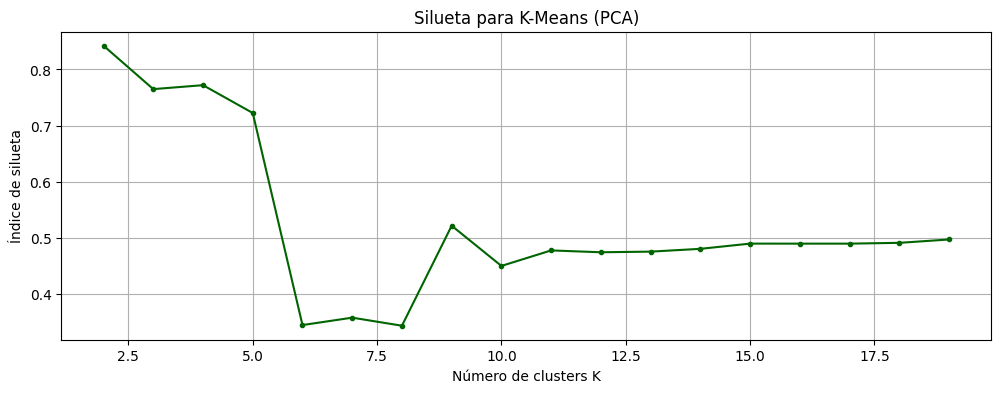

In [59]:
# Primero la silueta

X_pca_reduced = pca.fit_transform(X_scaled)

sil_scores_pca = []

for K in K_range:
    kmeans = KMeans(n_clusters=K, random_state=1008, n_init='auto')
    labels = kmeans.fit_predict(X_pca_reduced)
    score = silhouette_score(X_pca_reduced, labels)
    sil_scores_pca.append(score)
    print(f"K={K}: Silhouette Score (PCA) = {score:.4f}")

# Gráfico de silueta PCA
plt.figure(figsize=(12, 4))
plt.plot(K_range, sil_scores_pca, marker='o', markersize=3, color='darkgreen')
plt.xlabel('Número de clusters K')
plt.ylabel('Índice de silueta')
plt.title('Silueta para K-Means (PCA)')
plt.grid(True)
plt.savefig("silueta2.pdf")
plt.show()

In [60]:
# Evaluación con el K óptimo

k_optimo_pca = 6
kmeans_pca_optimo = KMeans(n_clusters=k_optimo_pca, random_state=1008, n_init='auto')
clusters_pca_optimo = kmeans_pca_optimo.fit_predict(X_pca_reduced)

In [61]:
# Evaluación en K=2

kmeans_pca_k2 = KMeans(n_clusters=2, random_state=1008, n_init='auto')
clusters_pca_k2 = kmeans_pca_k2.fit_predict(X_pca_reduced)

In [62]:
# Para graficar ahorita...

df_pca = pd.DataFrame({
    'PC1': X_pca_reduced[:, 0],
    'PC2': X_pca_reduced[:, 1],
    'Cluster_Optimo': clusters_pca_optimo,
    'Cluster_K2': clusters_pca_k2
})

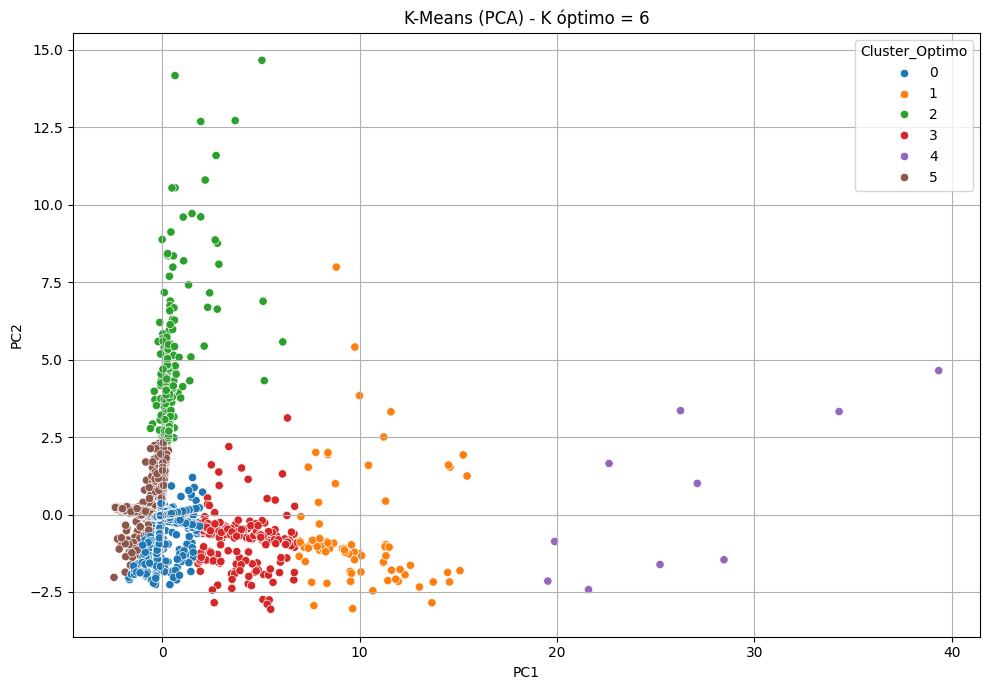

In [67]:
# Visualización K óptimo

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster_Optimo', palette='tab10')
plt.title(f'K-Means (PCA) - K óptimo = {k_optimo_pca}')
plt.grid(True)
plt.tight_layout()
plt.savefig("KoptKmeansPCA.pdf")
plt.show()

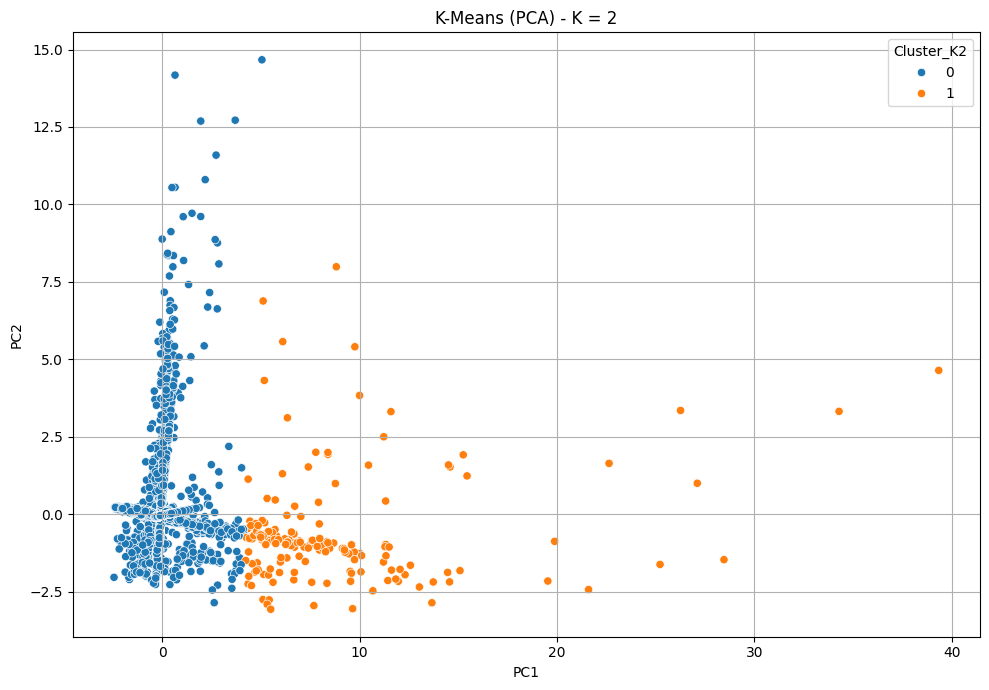

In [66]:
# Visualización K=2

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster_K2', palette='tab10')
plt.title(f'K-Means (PCA) - K = 2')
plt.grid(True)
plt.tight_layout()
plt.savefig("K2KmeansPCA.pdf")
plt.show()

In [91]:
# Ver los elementos principales de los clusters
# Primero el de 6

mat_clusters_pca = mat.copy()
mat_clusters_pca['cluster'] = clusters_pca_optimo
songs_clustered_pca = mat_clusters_pca.join(song_meta, how='left')

for c in range(k_optimo_pca):
    print(f"\n=== Cluster {c} (K óptimo) ===")
    subset = songs_clustered_pca[songs_clustered_pca['cluster'] == c]
    subset = subset.assign(total_score=subset[mat.columns].sum(axis=1))
    display(subset.sort_values("total_score", ascending=False)[['title', 'artist', 'total_score']].head(10))
    print(f"Total canciones: {len(subset[['title', 'artist', 'total_score']])}")


=== Cluster 0 (K óptimo) ===


,title,artist,total_score
song_id,,,
"MERRY-GO-ROUND (Feat. Zion.T, Wonstein) (Prod. Slom) — sokodomo","MERRY-GO-ROUND (Feat. Zion.T, Wonstein) (Prod....",sokodomo,10.475444
Limousine (Feat. MINO) (Prod. GRAY) — BE'O,Limousine (Feat. MINO) (Prod. GRAY),BE'O,10.331833
"打上花火 — DAOKO, Kenshi Yonezu",打上花火,"DAOKO, Kenshi Yonezu",9.097113
Etnaset — Muslim - مُسلِم,Etnaset,Muslim - مُسلِم,9.062034
"Keify Keda — Wegz, Disco Misr",Keify Keda,"Wegz, Disco Misr",9.052172
Pretender — Official HIGE DANdism,Pretender,Official HIGE DANdism,8.849455
Wherever you are — ONE OK ROCK,Wherever you are,ONE OK ROCK,8.390724
紅蓮華 — LiSA,紅蓮華,LiSA,8.330964
マリーゴールド — Aimyon,マリーゴールド,Aimyon,8.251164


Total canciones: 3436

=== Cluster 1 (K óptimo) ===


,title,artist,total_score
song_id,,,
Let It Snow! Let It Snow! Let It Snow! (with The B. Swanson Quartet) — Frank Sinatra,Let It Snow! Let It Snow! Let It Snow! (with T...,Frank Sinatra,38.798889
Feliz Navidad — José Feliciano,Feliz Navidad,José Feliciano,38.345854
Holly Jolly Christmas — Michael Bublé,Holly Jolly Christmas,Michael Bublé,37.116236
Mistletoe — Justin Bieber,Mistletoe,Justin Bieber,36.492762
Underneath the Tree — Kelly Clarkson,Underneath the Tree,Kelly Clarkson,35.140585
The Christmas Song (Merry Christmas To You) — Nat King Cole,The Christmas Song (Merry Christmas To You),Nat King Cole,35.082570
Blinding Lights — The Weeknd,Blinding Lights,The Weeknd,34.564416
Dance Monkey — Tones And I,Dance Monkey,Tones And I,33.197421
"White Christmas — Bing Crosby, Ken Darby Singers, John Scott Trotter & His Orchestra",White Christmas,"Bing Crosby, Ken Darby Singers, John Scott Tro...",32.078933


Total canciones: 78

=== Cluster 2 (K óptimo) ===


...

Total canciones: 225

=== Cluster 4 (K óptimo) ===


,title,artist,total_score
song_id,,,
All I Want for Christmas Is You — Mariah Carey,All I Want for Christmas Is You,Mariah Carey,101.905318
Last Christmas — Wham!,Last Christmas,Wham!,86.465667
Rockin' Around The Christmas Tree — Brenda Lee,Rockin' Around The Christmas Tree,Brenda Lee,64.875670
Jingle Bell Rock — Bobby Helms,Jingle Bell Rock,Bobby Helms,64.642084
It's Beginning to Look a Lot like Christmas — Michael Bublé,It's Beginning to Look a Lot like Christmas,Michael Bublé,63.786162
It's the Most Wonderful Time of the Year — Andy Williams,It's the Most Wonderful Time of the Year,Andy Williams,57.857942
Santa Tell Me — Ariana Grande,Santa Tell Me,Ariana Grande,56.570161
Fairytale of New York (feat. Kirsty MacColl) — The Pogues,Fairytale of New York (feat. Kirsty MacColl),The Pogues,53.157256
Easy On Me — Adele,Easy On Me,Adele,47.635104


Total canciones: 10

=== Cluster 5 (K óptimo) ===


,title,artist,total_score
song_id,,,
Algo Tiene — Natalie Perez,Algo Tiene,Natalie Perez,2.824441
Si Te Lastime — Seven Kayne,Si Te Lastime,Seven Kayne,2.620458
"Besos En Guerra — Morat, Juanes",Besos En Guerra,"Morat, Juanes",2.575241
Jurabas Tu — Los del Fuego,Jurabas Tu,Los del Fuego,2.448494
Campana Sobre Campana — Yuri,Campana Sobre Campana,Yuri,2.444574
C90 — John C,C90,John C,2.431748
Arre Borriquito — Denise De Kalafe,Arre Borriquito,Denise De Kalafe,2.416642
Let Me Down Slowly — Alec Benjamin,Let Me Down Slowly,Alec Benjamin,2.399564
"El Tóxico — Grupo Firme, Carin Leon",El Tóxico,"Grupo Firme, Carin Leon",2.387170


Total canciones: 2557


In [92]:
# Ahora el de K=2
mat_clusters_pca_k2 = mat.copy()
mat_clusters_pca_k2['cluster'] = clusters_pca_k2
songs_clustered_pca_k2 = mat_clusters_pca_k2.join(song_meta, how='left')

for c in range(2):
    print(f"\n=== Cluster {c} (K=2) ===")
    subset = songs_clustered_pca_k2[songs_clustered_pca_k2['cluster'] == c]
    subset = subset.assign(total_score=subset[mat.columns].sum(axis=1))
    display(subset.sort_values("total_score", ascending=False)[['title', 'artist', 'total_score']].head(10))
    print(f"Total canciones: {len(subset[['title', 'artist', 'total_score']])}")


=== Cluster 0 (K=2) ===


,title,artist,total_score
song_id,,,
"DÁKITI — Bad Bunny, Jhay Cortez",DÁKITI,"Bad Bunny, Jhay Cortez",23.110798
"Taki Taki (with Selena Gomez, Ozuna & Cardi B) — DJ Snake","Taki Taki (with Selena Gomez, Ozuna & Cardi B)",DJ Snake,19.774545
"Calma - Remix — Pedro Capó, Farruko",Calma - Remix,"Pedro Capó, Farruko",16.714531
"Tusa — KAROL G, Nicki Minaj",Tusa,"KAROL G, Nicki Minaj",15.120117
Adan y Eva — Paulo Londra,Adan y Eva,Paulo Londra,15.035133
"Échame La Culpa — Luis Fonsi, Demi Lovato",Échame La Culpa,"Luis Fonsi, Demi Lovato",14.288698
"Corazón — Maluma, Nego do Borel",Corazón,"Maluma, Nego do Borel",14.227202
MIA (feat. Drake) — Bad Bunny,MIA (feat. Drake),Bad Bunny,13.955347
"LA NOCHE DE ANOCHE — Bad Bunny, ROSALÍA",LA NOCHE DE ANOCHE,"Bad Bunny, ROSALÍA",13.314758


Total canciones: 6357

=== Cluster 1 (K=2) ===


,title,artist,total_score
song_id,,,
All I Want for Christmas Is You — Mariah Carey,All I Want for Christmas Is You,Mariah Carey,101.905318
Last Christmas — Wham!,Last Christmas,Wham!,86.465667
Rockin' Around The Christmas Tree — Brenda Lee,Rockin' Around The Christmas Tree,Brenda Lee,64.875670
Jingle Bell Rock — Bobby Helms,Jingle Bell Rock,Bobby Helms,64.642084
It's Beginning to Look a Lot like Christmas — Michael Bublé,It's Beginning to Look a Lot like Christmas,Michael Bublé,63.786162
It's the Most Wonderful Time of the Year — Andy Williams,It's the Most Wonderful Time of the Year,Andy Williams,57.857942
Santa Tell Me — Ariana Grande,Santa Tell Me,Ariana Grande,56.570161
Fairytale of New York (feat. Kirsty MacColl) — The Pogues,Fairytale of New York (feat. Kirsty MacColl),The Pogues,53.157256
Easy On Me — Adele,Easy On Me,Adele,47.635104


Total canciones: 179


###### 3.1.3. Con escalado para los países

In [70]:
from sklearn.cluster import AgglomerativeClustering

In [71]:
# Los países tienen el efecto al revés...

mat_country = mat.transpose()
# mat_country.head()
Y = mat_country.values

scaler_country = StandardScaler()
Y_scaled = scaler_country.fit_transform(Y)

K=2: Silhouette Score (Países) = 0.0758
K=3: Silhouette Score (Países) = 0.0756
K=4: Silhouette Score (Países) = 0.0816
K=5: Silhouette Score (Países) = 0.0749
K=6: Silhouette Score (Países) = 0.0624
K=7: Silhouette Score (Países) = 0.0575
K=8: Silhouette Score (Países) = 0.0451


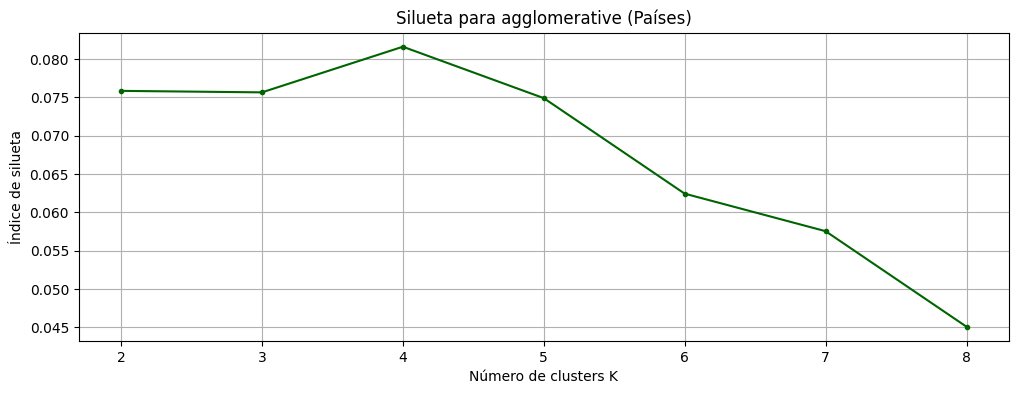

In [80]:
# Va la silueta

sil_scores_country = []

for K in K_range[0:7]:
    agg = AgglomerativeClustering(n_clusters=K, linkage='ward')
    labels = agg.fit_predict(Y_scaled)
    score = silhouette_score(Y_scaled, labels)
    sil_scores_country.append(score)
    print(f"K={K}: Silhouette Score (Países) = {score:.4f}")

# Gráfico de silueta escalado países
plt.figure(figsize=(12, 4))
plt.plot(K_range[0:7], sil_scores_country, marker='o', markersize=3, color='darkgreen')
plt.xlabel('Número de clusters K')
plt.ylabel('Índice de silueta')
plt.title('Silueta para agglomerative (Países)')
plt.grid(True)
plt.savefig("silueta3.pdf")
plt.show()

In [81]:
# Primero con el k optimo (que en realidad no aporta nada...)

k_optimo_country = 6
agg_optimo = AgglomerativeClustering(n_clusters=k_optimo_country, linkage='ward')
country_labels_optimo = agg_optimo.fit_predict(Y_scaled)

In [82]:
# Ahora con K=2

agg_k2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
country_labels_k2 = agg_k2.fit_predict(Y_scaled)

In [83]:
# PCA para graficar

pca_country = PCA(n_components=2, random_state=1008)
Y_pca = pca_country.fit_transform(Y_scaled)

df_country = pd.DataFrame({
    'PC1': Y_pca[:, 0],
    'PC2': Y_pca[:, 1],
    'Cluster_Optimo': country_labels_optimo,
    'Cluster_K2': country_labels_k2
})

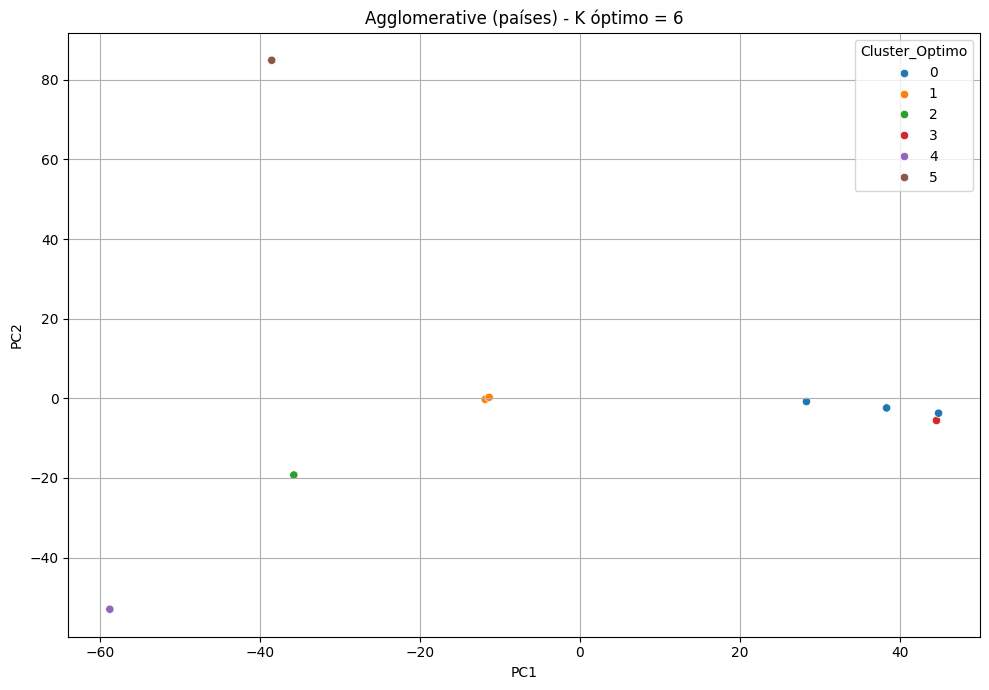

In [84]:
# Visualización K óptimo

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_country, x='PC1', y='PC2', hue='Cluster_Optimo', palette='tab10')
plt.title(f'Agglomerative (países) - K óptimo = {k_optimo_pca}')
plt.grid(True)
plt.tight_layout()
plt.savefig("Agglomerative.pdf")
plt.show()

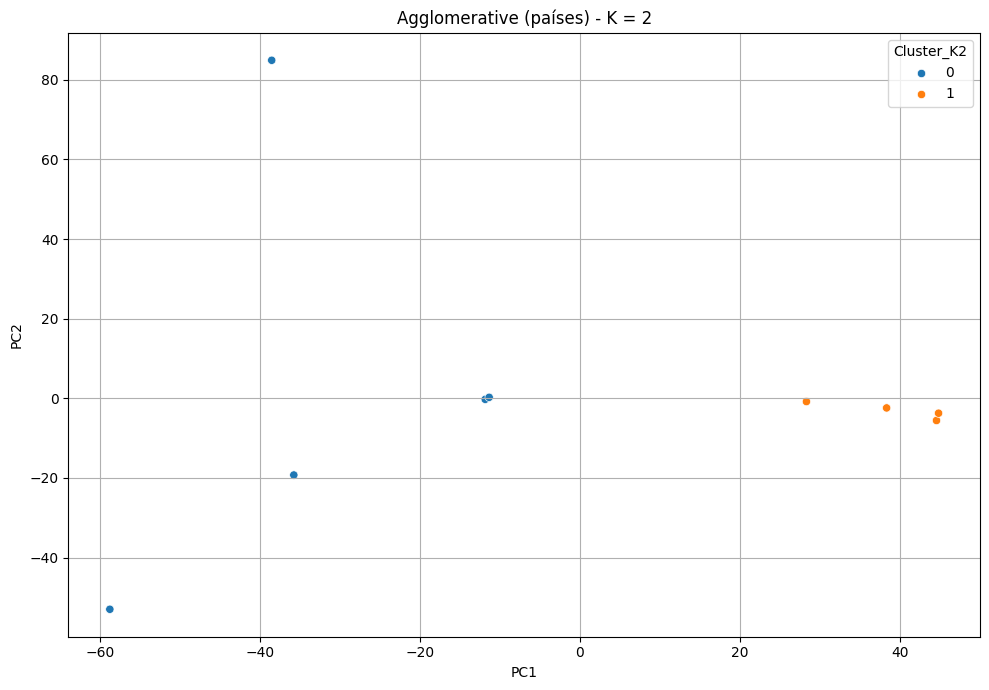

In [85]:
# Visualización K óptimo

plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_country, x='PC1', y='PC2', hue='Cluster_K2', palette='tab10')
plt.title(f'Agglomerative (países) - K = 2')
plt.grid(True)
plt.tight_layout()
plt.savefig("Agglomerative2.pdf")
plt.show()

In [88]:
# Clusters optimos (que no dicen nada...)

country_clusters = mat_country.copy()
country_clusters['cluster'] = country_labels_optimo
print("\nClusters óptimos para países:")
display(country_clusters[['cluster']].head(10))


Clusters óptimos para países:


song_id,cluster
region,
Argentina,4
Canada,0
Egypt,1
Global,0
Japan,5
Mexico,2
South Korea,1
United Kingdom,3
United States,0


In [89]:
# Clusters con K=2

country_clusters_k2 = mat_country.copy()
country_clusters_k2['cluster'] = country_labels_k2
print("\nClusters K=2 para países:")
display(country_clusters_k2[['cluster']].head(10))


Clusters K=2 para países:


song_id,cluster
region,
Argentina,0
Canada,1
Egypt,0
Global,1
Japan,0
Mexico,0
South Korea,0
United Kingdom,1
United States,1


##### 3.2. Con spectral clustering
Aquí se hacen el proceso de ubicación de *canciones navideñas* y de *países navideños* con spectral clustering.

Se revisan los casos de preprocesamiento por escalado y por PCA.

In [96]:
from sklearn.cluster import SpectralClustering

###### 3.2.1. Con escalado para las canciones

K=2: Silhouette Score (Spectral) = -0.2935
K=3: Silhouette Score (Spectral) = -0.2661
K=4: Silhouette Score (Spectral) = -0.2739
K=5: Silhouette Score (Spectral) = -0.2711
K=6: Silhouette Score (Spectral) = -0.2548
K=7: Silhouette Score (Spectral) = -0.1603
K=8: Silhouette Score (Spectral) = -0.0893
K=9: Silhouette Score (Spectral) = -0.0502
K=10: Silhouette Score (Spectral) = -0.0495
K=11: Silhouette Score (Spectral) = -0.0715
K=12: Silhouette Score (Spectral) = -0.0548
K=13: Silhouette Score (Spectral) = -0.0762
K=14: Silhouette Score (Spectral) = -0.0788
K=15: Silhouette Score (Spectral) = -0.0367
K=16: Silhouette Score (Spectral) = -0.0397
K=17: Silhouette Score (Spectral) = -0.0380
K=18: Silhouette Score (Spectral) = -0.0342
K=19: Silhouette Score (Spectral) = 0.0104


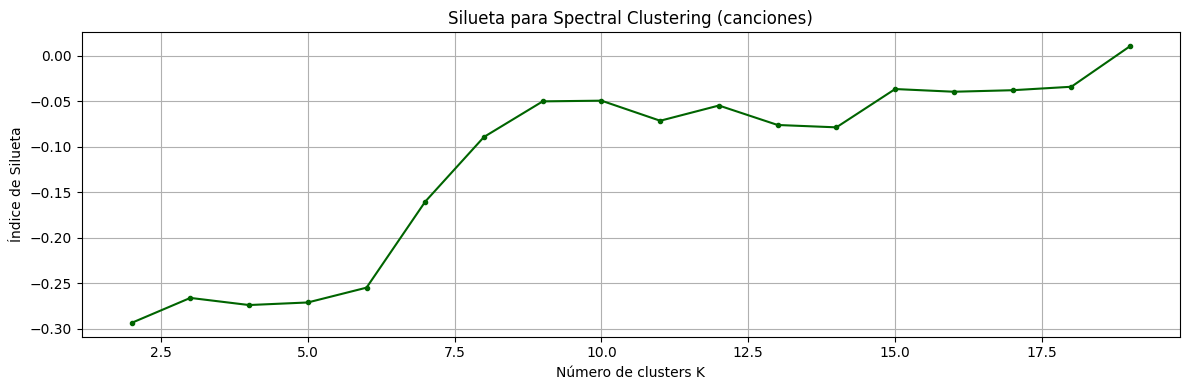

In [97]:
# Primero reduzco con PCA a 5 componentes
# Para el Spectral Clustering es NECESARIO hacerlo con afinidad por primeros vecinos

sil_scores_spec = []

pca_spectral = PCA(n_components=5, random_state=1008)
X_low = pca_spectral.fit_transform(X_scaled)

for K in K_range:
    spectral = SpectralClustering(
        n_clusters=K,
        affinity="nearest_neighbors",
        n_neighbors=20,
        assign_labels="kmeans",
        random_state=1008
    )
    labels = spectral.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores_spec.append(score)
    print(f"K={K}: Silhouette Score (Spectral) = {score:.4f}")

# Gráfico de silueta
plt.figure(figsize=(12, 4))
plt.plot(list(K_range), sil_scores_spec, marker='o', markersize=3, color='darkgreen')
plt.xlabel('Número de clusters K')
plt.ylabel('Índice de Silueta')
plt.title('Silueta para Spectral Clustering (canciones)')
plt.tight_layout()
plt.grid(True)
plt.savefig("silueta_spectral_canciones.pdf")
plt.show()

In [98]:
# Primero K óptimo

k_optimo_spec = 6
spectral_opt = SpectralClustering(
    n_clusters=k_optimo_spec,
    affinity="nearest_neighbors",
    n_neighbors=20,
    assign_labels="kmeans",
    random_state=1008
)
clusters_spec_opt = spectral_opt.fit_predict(X_low)

In [99]:
# Ahora K=2

spectral_k2 = SpectralClustering(
    n_clusters=2,
    affinity="nearest_neighbors",
    n_neighbors=20,
    assign_labels="kmeans",
    random_state=1008
)
clusters_spec_k2 = spectral_k2.fit_predict(X_low)


In [100]:
# El DF para graficar

df_spec_songs = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster_Spec_Optimo': clusters_spec_opt,
    'Cluster_Spec_K2': clusters_spec_k2
})

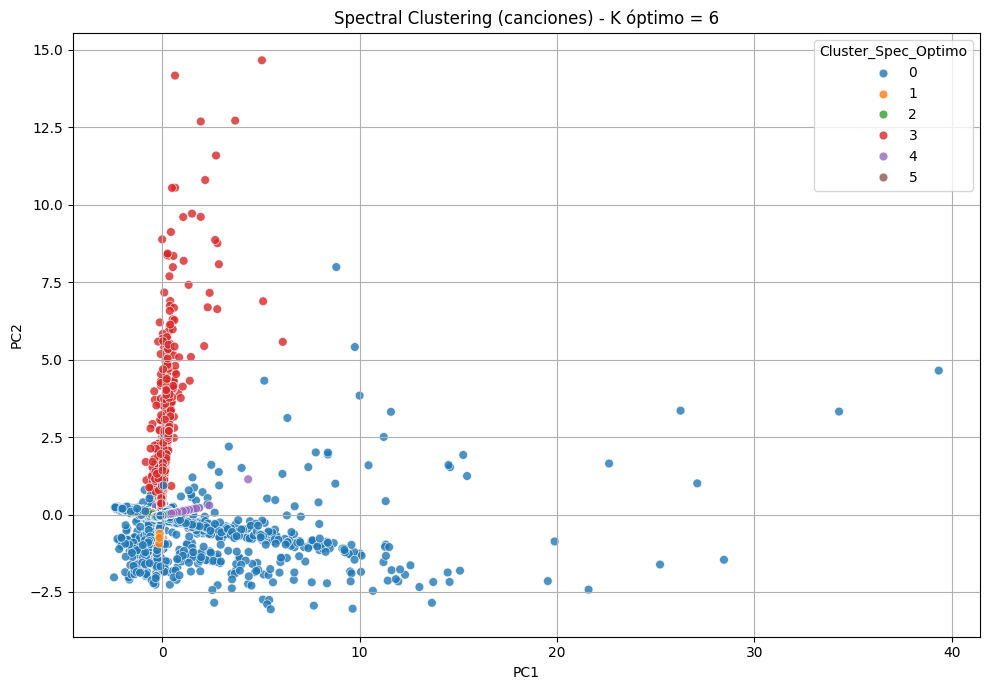

In [101]:
# Visualización en K óptimo

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_spec_songs,
    x='PC1',
    y='PC2',
    hue='Cluster_Spec_Optimo',
    palette='tab10',
    s=40,
    alpha=0.8
)
plt.title(f'Spectral Clustering (canciones) - K óptimo = {k_optimo_spec}')
plt.grid(True)
plt.tight_layout()
plt.savefig("SpectralSongs_Kopt.pdf")
plt.show()

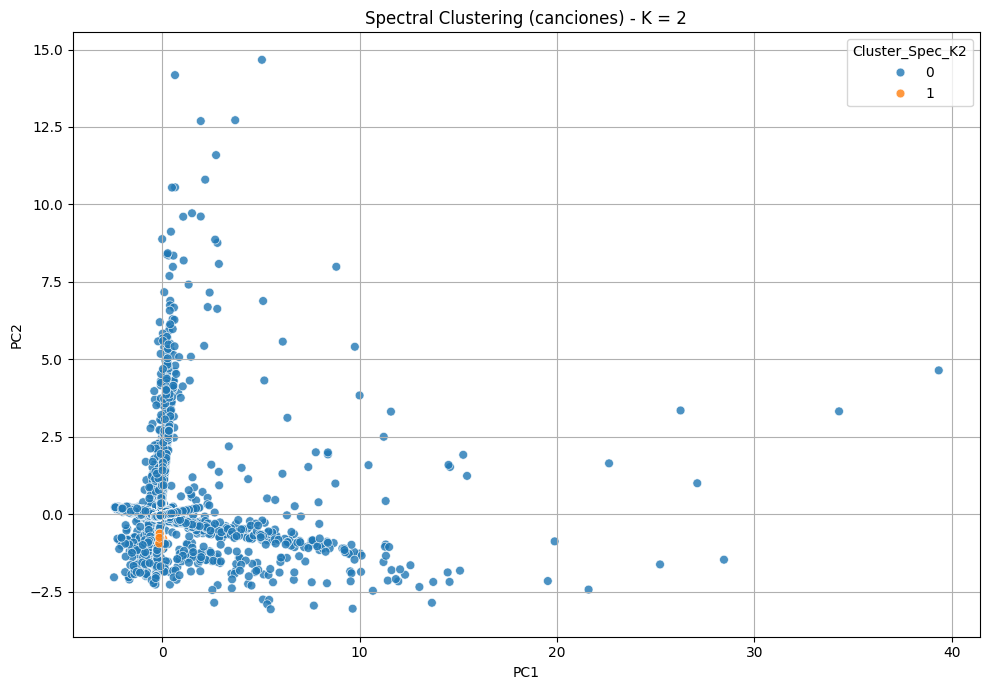

In [102]:
# Visualización con K=2

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_spec_songs,
    x='PC1',
    y='PC2',
    hue='Cluster_Spec_K2',
    palette='tab10',
    s=40,
    alpha=0.8
)
plt.title('Spectral Clustering (canciones) - K = 2')
plt.grid(True)
plt.tight_layout()
plt.savefig("SpectralSongs_K2.pdf")
plt.show()